# Running Model Inference

This tutorial demonstrates the ML inference capabilities of `imfusion-sdk`.

The  `imfusion.machinelearning.MachineLearning` class allows running a model on some input data while taking care of pre- and postprocessing as well as sampling/tiling.
One major advantage of this approach is that this class can reuse the exact same preprocessing that was used for training (see previous notebook) and therefore avoid unexpected deviations in the input images.

 It consists of the following building blocks:

- ModelFile: filename of the exported (traced) ML model.
- Engine: An engine that forwards the preprocessed/sampled input to the machine learning framework that runs the saved model.
- Preprocessing: A preprocessing pipeline that matches the (deterministic) pipeline used for training.
- Postprocessing: A postprocessing pipeline that performs additional handling of the model output.
- Sampling: A strategy for sampling the input and recombining the predictions.

The configuration of a model is controlled by an inference YAML file.

## Notebook bootstrap


In [1]:
import sys
from pathlib import Path

shared_dir = next(path / "shared" for path in [Path.cwd(), *Path.cwd().parents] if (path / "shared").is_dir())
if str(shared_dir) not in sys.path:
    sys.path.append(str(shared_dir))

from demo_utils import unzip_folder, mpr_plot



## Example: Inference Yaml Configuration

In [2]:
%cat resources/model_onnx.yaml

Version: 5.0
Type: NeuralNetwork
PredictionType: CLASSIFICATION
PredictionOutput: IMAGE
Name: Overfitting Segmentation
Description: Dummy model for the public demo material

# This selects which framework runs the prediction, can be ['pytorch', 'pyonnxruntime', 'pyopenvino'].
# If `imfusion` includes the TorchPlugin and OnnxPlugin then `torch` and `onnx` are also available.
Engine: pyonnxruntime

# Path to the saved inference model relative to this file.
ModelFile: model.onnx

ForceCPU: false # Option for forcing execution on CPU. Default: false.
Verbose: false  # Option for enabling additional logging during execution. Default: false.

# Defines the processing pipeline before invoking the model.
# Entries are specified as the names of imfusion.machinelearning.Operation subclasses (but without the `Operation` suffix)
PreProcessing:
- MakeFloat:	# Converts the image voxels to float type
- NormalizePercentile:	# Normalizes the voxel values to [0, 1] while taking into account only min to 

In [3]:
import imfusion
import imfusion.machinelearning as ml

unzipped_folder = unzip_folder("../shared/data/pet-ct-rtstruct.zip")

ct_image, *_ = imfusion.io.load("../shared/data/pet-ct-rtstruct/ct.imf")
bones_segmentation, *_ = imfusion.io.load("../shared/data/pet-ct-rtstruct/bones.imf")


The interface for using `MachineLearningModel` is quite straightforward:
We just need to supply a configuration yaml (shown above) to construct it and then call `.predict` and pass in the input data.

In [4]:
# Specify a path the inference yaml config
# (This is a dummy model prepared for the tutorial, briefly trained only on this example)
inference_yaml_config = 'resources/model_onnx.yaml'
# Set up the ML model
model = ml.MachineLearningModel(inference_yaml_config)
# Run the inference
pred_segmentation = model.predict(ct_image)
imfusion.io.save(pred_segmentation, 'output/pred_segmentation.imf')
pred_segmentation

imfusion.SharedImageSet(size: 1, [imfusion.SharedImage(UBYTE width: 167 height: 167 slices: 247 spacing: 3 mm)])

Target:


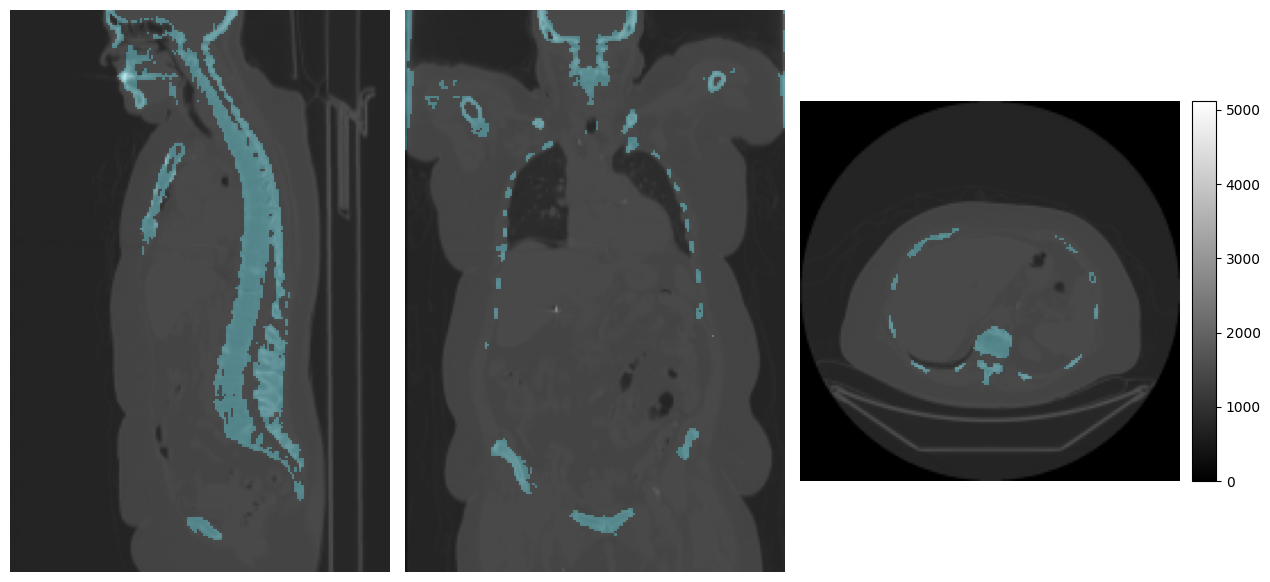

Prediction:


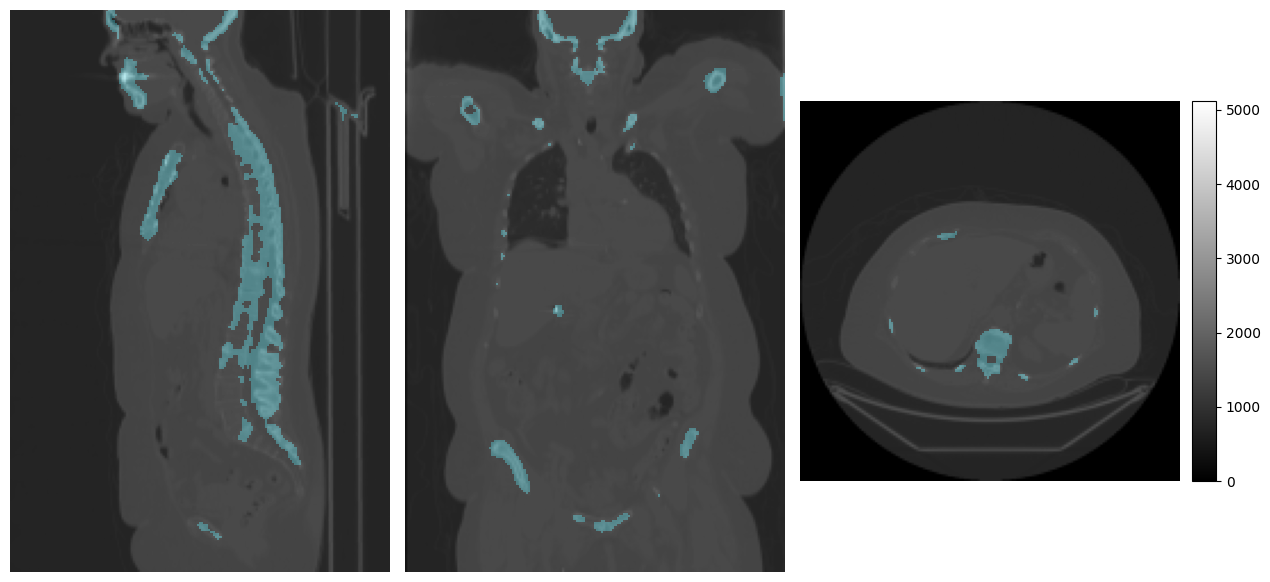

In [5]:
# Visualize the ground truth
print("Target:")
mpr_plot(ct_image[0], labels=bones_segmentation[0])

# Visualize the prediction
print("Prediction:")
mpr_plot(ct_image[0], labels=pred_segmentation[0])

None

In [6]:
# Compute the dice score
dice_score = ml.DiceMetric().compute_dice(pred_segmentation, bones_segmentation)

# dice_score structure: List refers to each image in the image set, in this case only 1
# Dict refers to the label values, 0 = background, 1 = bone.
print(dice_score[0])

{1: 0.645042642697869}
